In [2]:
import pandas as pd
from pathlib import Path
from scipy import stats
from scipy.stats import friedmanchisquare
import itertools
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

In [3]:
us_ensemble_metrics_dir = Path("../../2_final_runs/2_us_127_basins/ensemble_testing_metrics") #US
us_ensemble_peak_metrics_dir = Path("../../2_final_runs/2_us_127_basins/ensemble_peak_metrics") #US

In [4]:
# caravan_metrics = pd.read_csv(ensemble_metrics_dir / "precip_prcp_mm_day.csv")
# chirps_metrics = pd.read_csv(ensemble_metrics_dir / "precip_prcp_chirps_mm_day.csv")
# mswep_metrics = pd.read_csv(ensemble_metrics_dir / "precip_prcp_mswep_mm_day.csv")
# gauge_metrics = pd.read_csv(ensemble_metrics_dir / "precip_prcp_gauge_mm_day.csv")
# chirps_mswep_metrics = pd.read_csv(ensemble_metrics_dir / "precip_prcp_chirps_mm_day_prcp_mswep_mm_day.csv")
# chirps_mswep_gauge_metrics = pd.read_csv(ensemble_metrics_dir / "precip_prcp_chirps_mm_day_prcp_mswep_mm_day_prcp_gauge_mm_day.csv")

In [5]:
# caravan_metrics

In [6]:
# nse_df = pd.DataFrame({
#     'caravan':          caravan_metrics['NSE'].values,
#     'chirps':           chirps_metrics['NSE'].values,
#     'mswep':            mswep_metrics['NSE'].values,
#     'gauge':            gauge_metrics['NSE'].values,
#     'chirps_mswep':     chirps_mswep_metrics['NSE'].values,
#     'chirps_mswep_gauge': chirps_mswep_gauge_metrics['NSE'].values,
# }, index=caravan_metrics['basin_id'])  # use basin as index

# nse_df

In [7]:
# def build_metric_df(dataframes, names, metric, index_col='basin_id'):
#     return pd.DataFrame(
#         {name: df[metric].values for name, df in zip(names, dataframes)},
#         index=dataframes[0][index_col]
#     )

# # Define once
# dfs   = [caravan_metrics, chirps_metrics, mswep_metrics, 
#          gauge_metrics, chirps_mswep_metrics, chirps_mswep_gauge_metrics]
# names = ['caravan', 'chirps', 'mswep', 
#          'gauge', 'chirps_mswep', 'chirps_mswep_gauge']

# # Build for each metric
# nse_df  = build_metric_df(dfs, na# USUmes, 'NSE')
# rmse_df = build_metric_df(dfs, names, 'RMSE')
# mse_df  = build_metric_df(dfs, names, 'MSE')
# kge_df  = build_metric_df(dfs, names, 'Beta-KGE')
# fhv_df  = build_metric_df(dfs, names, 'FHV')
# fms_df  = build_metric_df(dfs, names, 'FMS')
# flv_df  = build_metric_df(dfs, names, 'FLV')
# peak_timing_df  = build_metric_df(dfs, names, 'Peak-Timing')
# missed_peaks_df  = build_metric_df(dfs, names, 'Missed-Peaks')
# peak_mape_df  = build_metric_df(dfs, names, 'Peak-MAPE')

# def shapiro_test(df, metric_name):
#     print(f"\nShapiro-Wilk — {metric_name}")
#     print("=" * 45)
#     for model in df.columns:
#         stat, p = stats.shapiro(df[model])
#         normal = "Normal" if p > 0.05 else "Non-normal"
#         print(f"{model:20s}  W={stat:.4f}  p={p:.4f}  {normal}")

# shapiro_test(nse_df,         'NSE')
# shapiro_test(rmse_df,        'RMSE')
# shapiro_test(mse_df,         'MSE')
# shapiro_test(kge_df,         'Beta-KGE')  # kge_df → Beta-KGE
# shapiro_test(fhv_df,         'FHV')       # fhv_df → FHV
# shapiro_test(fms_df,         'FMS')       # fms_df → FMS
# shapiro_test(flv_df,         'FLV')
# shapiro_test(peak_timing_df, 'Peak-Timing')
# shapiro_test(missed_peaks_df,'Missed-Peaks')
# shapiro_test(peak_mape_df,   'Peak-MAPE')

# US (CHIRPS_v2 or CHIRPS_v3)

In [8]:
# # US
# run_metrics = ['camels_precipitation_seq_270_1_epochs_30_hidden_256_dropout_04_fb_5', #CAMELS
#                "total_precipitation_sum_seq_270_1_epochs_30_hidden_256_dropout_04_fb_5", #CARAVAN
#                # 'chirps_precipitation_seq_270_1_epochs_30_hidden_256_dropout_04_fb_5', #CHIRPS
#                'chirps_precipitation_seq_270_1_epochs_30_hidden_256_dropout_04_fb_5', #CHIRPS_v3
#                'mswep_precipitation_seq_270_1_epochs_30_hidden_256_dropout_04_fb_5', #MSWEP
#                # 'mswep_precipitation_chirps_precipitation_seq_270_1_epochs_30_hidden_256_dropout_04_fb_5' #MSWEP + CHIRPS
#                'chirps_precipitation_mswep_precipitation_seq_270_1_epochs_30_hidden_256_dropout_04_fb_5' #MSWEP + CHIRPS_v3
#                ] 

In [9]:
run_configs = [
    ('camels',      'camels_precipitation_seq_270_1_epochs_30_hidden_256_dropout_04_fb_5'),
    ('caravan',     'total_precipitation_sum_seq_270_1_epochs_30_hidden_256_dropout_04_fb_5'),
    ('chirps',      'chirps_precipitation_seq_270_1_epochs_30_hidden_256_dropout_04_fb_5'),
    ('mswep',       'mswep_precipitation_seq_270_1_epochs_30_hidden_256_dropout_04_fb_5'),
    ('chirps_mswep','chirps_precipitation_mswep_precipitation_seq_270_1_epochs_30_hidden_256_dropout_04_fb_5'),
]

model_labels = [label for label, _ in run_configs]
run_metrics  = [run   for _, run   in run_configs]

In [10]:
# model_labels = [
#     'camels', 'caravan', 'chirps', 'mswep', 'chirps_mswep'
# ]

metric_names = [
    'Peak-MAPE', 'Missed-Peaks', 'Peak-Timing',
    'FLV', 'FMS', 'FHV',
    'Beta-KGE', 'MSE', 'RMSE', 'NSE'
]

In [11]:
# ── Load data ────────────────────────────────────────────────────────────────
all_metrics = {m: [] for m in metric_names}
basins_order = []

for i, run_name in enumerate(run_metrics):
    metrics_csv = pd.read_csv(us_ensemble_metrics_dir / f"{run_name}.csv")
    peak_metrics_csv = pd.read_csv(us_ensemble_peak_metrics_dir / f"{run_name}.csv")

    if i == 0:
        basins_order = metrics_csv["basin_id"].values

    # for metric in metric_names:
    #     all_metrics[metric].append(metrics_csv[metric].values)

    for metric in metric_names:
        if metric in ['Missed-Peaks', 'Peak-Timing']:
            all_metrics[metric].append(peak_metrics_csv[metric].values)
        else:
            all_metrics[metric].append(metrics_csv[metric].values)

# ── Build per-metric DataFrames ───────────────────────────────────────────────
metric_dfs = {
    metric: pd.DataFrame(
        dict(zip(model_labels, arrays)),
        index=basins_order
    )
    for metric, arrays in all_metrics.items()
}

# Rename "Beta-KGE" to "Mean ratio"
metric_dfs["Mean ratio"] = metric_dfs.pop("Beta-KGE")

In [12]:
# ── Friedman test ─────────────────────────────────────────────────────────────
def friedman_test(df, metric_name):
    data = [df[col].dropna().values for col in df.columns]
    stat, p = friedmanchisquare(*data)

    k = len(df.columns)
    n = len(df)
    W = stat / (n * (k - 1))

    if W < 0.1:
        effect = "negligible"
    elif W < 0.3:
        effect = "small"
    elif W < 0.5:
        effect = "moderate"
    else:
        effect = "large"

    print(f"\n{'='*55}")
    print(f"  Friedman Test — {metric_name}")
    print(f"{'='*55}")
    print(f"  χ²           = {stat:.4f}")
    print(f"  p-value      = {p:.4f}")
    print(f"  Kendall W    = {W:.4f} ({effect} effect)")
    print(f"  n catchments = {n}, k models = {k}")
    print(f"\n  {'Significant difference between models (p < 0.05)' if p < 0.05 else 'No significant difference between models (p >= 0.05)'}")

    return stat, p, W

In [13]:
# ── Run for all metrics ───────────────────────────────────────────────────────
results = {}
for metric, df in metric_dfs.items():
    stat, p, W = friedman_test(df, metric)
    results[metric] = {'stat': stat, 'p': p, 'W': W}


  Friedman Test — Peak-MAPE
  χ²           = 170.1354
  p-value      = 0.0000
  Kendall W    = 0.3349 (moderate effect)
  n catchments = 127, k models = 5

  Significant difference between models (p < 0.05)

  Friedman Test — Missed-Peaks
  χ²           = 212.4434
  p-value      = 0.0000
  Kendall W    = 0.4182 (moderate effect)
  n catchments = 127, k models = 5

  Significant difference between models (p < 0.05)

  Friedman Test — Peak-Timing
  χ²           = 102.8736
  p-value      = 0.0000
  Kendall W    = 0.2025 (small effect)
  n catchments = 127, k models = 5

  Significant difference between models (p < 0.05)

  Friedman Test — FLV
  χ²           = 68.2016
  p-value      = 0.0000
  Kendall W    = 0.1343 (small effect)
  n catchments = 127, k models = 5

  Significant difference between models (p < 0.05)

  Friedman Test — FMS
  χ²           = 80.6299
  p-value      = 0.0000
  Kendall W    = 0.1587 (small effect)
  n catchments = 127, k models = 5

  Significant difference betw

In [14]:
friedman_ps = {metric: res['p'] for metric, res in results.items()}
friedman_ps

{'Peak-MAPE': np.float64(9.781386083590609e-36),
 'Missed-Peaks': np.float64(7.92091351969554e-45),
 'Peak-Timing': np.float64(2.403876523591192e-21),
 'FLV': np.float64(5.43917537367139e-14),
 'FMS': np.float64(1.2809801604061752e-16),
 'FHV': np.float64(4.0116774090322475e-32),
 'MSE': np.float64(9.073638784894808e-59),
 'RMSE': np.float64(9.073638784894808e-59),
 'NSE': np.float64(9.073638784894808e-59),
 'Mean ratio': np.float64(4.4216629380842166e-05)}

In [15]:
metric_targets = {
    'Peak-MAPE': 0,
    'Missed-Peaks': 0,
    'Peak-Timing': 0,
    'FLV': 0,
    'FMS': 0,
    'FHV': 0,
    'Mean ratio': 1,   # ← updated here
    'MSE': 0,
    'RMSE': 0,
    'NSE': 1
}

In [16]:
def posthoc_wilcoxon(df, metric_name, friedman_p, metric_targets):
    if friedman_p >= 0.05:
        print(f"\nSkipping post-hoc for {metric_name} — Friedman not significant (p={friedman_p:.4f})")
        return None
    
    models = df.columns.tolist()
    pairs  = list(itertools.combinations(models, 2))
    target = metric_targets[metric_name]
    
    rows = []
    for m1, m2 in pairs:
        diff      = df[m1].values - df[m2].values
        n_zeros   = (diff == 0).sum()
        n_effective = len(diff) - n_zeros

        if n_zeros > 0:
            print(f"  ⚠️  {metric_name} | {m1} vs {m2}: "
                  f"{n_zeros} tied pairs dropped (n_effective={n_effective})")

        stat, p_raw    = wilcoxon(df[m1].values, df[m2].values)
        median_diff    = np.median(diff)          # >0 → m1 tends higher, <0 → m2 tends higher
        median_m1      = df[m1].median()
        median_m2      = df[m2].median()

        # Direction: which model is closer to the target?
        # if abs(median_m1 - target) < abs(median_m2 - target):
        #     better = m1
        # elif abs(median_m2 - target) < abs(median_m1 - target):
        #     better = m2
        # else:
        #     better = 'tie'

        # Direction:
        dist_m1 = abs(median_m1 - target)
        dist_m2 = abs(median_m2 - target)

        if dist_m1 < dist_m2:
            better = m1
        elif dist_m2 < dist_m1:
            better = m2
        else:
            better = 'tie'

        rows.append({
            'model_1':      m1,
            'model_2':      m2,
            'median_m1':    median_m1,
            'median_m2':    median_m2,
            'median_diff':  median_diff,
            'better':       better,
            'p_raw':        p_raw,
            'n_zeros':      n_zeros,
            'n_effective':  n_effective,
        })
    
    results_df = pd.DataFrame(rows)
    
    _, p_corrected, _, _ = multipletests(results_df['p_raw'], method='bonferroni')
    results_df['p_corrected'] = p_corrected
    results_df['significant'] = p_corrected < 0.05

    print(f"\n{'='*80}")
    print(f"  Wilcoxon signed-rank + Bonferroni — {metric_name}  (target = {target})")
    print(f"{'='*80}")
    for _, row in results_df.iterrows():
        if row['significant']:
            sig = f"* {row['better']} better"
        else:
            sig = "  similar"
        zeros = f"  [⚠️  {int(row['n_zeros'])} ties]" if row['n_zeros'] > 0 else ""
        print(f"  {row['model_1']:20s} vs {row['model_2']:20s}  "
              f"med=({row['median_m1']:.3f} | {row['median_m2']:.3f})  "
              f"p_adj={row['p_corrected']:.4f}  {sig}{zeros}")
    
    return results_df


# ── Run for all metrics ───────────────────────────────────────────────────────
posthoc_results = {}
for metric, df in metric_dfs.items():
    result = posthoc_wilcoxon(df, metric, friedman_ps[metric], metric_targets)
    if result is not None:
        posthoc_results[metric] = result


  Wilcoxon signed-rank + Bonferroni — Peak-MAPE  (target = 0)
  camels               vs caravan               med=(41.178 | 65.118)  p_adj=0.0000  * camels better
  camels               vs chirps                med=(41.178 | 49.519)  p_adj=0.0018  * camels better
  camels               vs mswep                 med=(41.178 | 39.189)  p_adj=0.1250    similar
  camels               vs chirps_mswep          med=(41.178 | 40.322)  p_adj=0.6461    similar
  caravan              vs chirps                med=(65.118 | 49.519)  p_adj=0.0000  * chirps better
  caravan              vs mswep                 med=(65.118 | 39.189)  p_adj=0.0000  * mswep better
  caravan              vs chirps_mswep          med=(65.118 | 40.322)  p_adj=0.0000  * chirps_mswep better
  chirps               vs mswep                 med=(49.519 | 39.189)  p_adj=0.0000  * mswep better
  chirps               vs chirps_mswep          med=(49.519 | 40.322)  p_adj=0.0000  * chirps_mswep better
  mswep                vs chir

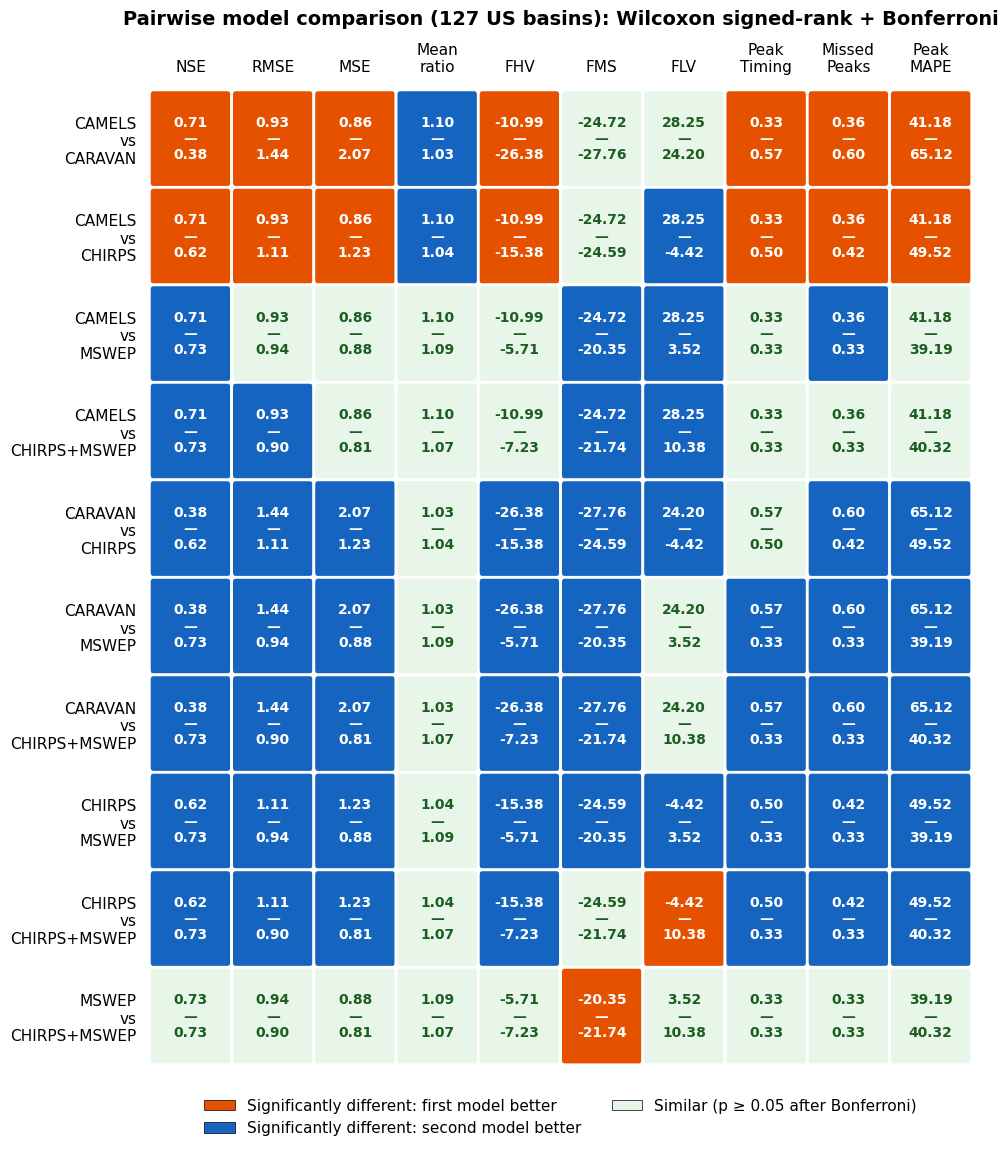

In [17]:
# ── Define models ──────────────────────────────────────────────────────────
models      = ['camels', 'caravan', 'chirps', 'mswep', 'chirps_mswep']
short_names = ['CAMELS', 'CARAVAN', 'CHIRPS', 'MSWEP', 'CHIRPS+MSWEP']

# ── Helper: get color key from posthoc_results ─────────────────────────────
skipped_metrics = [m for m, p in friedman_ps.items() if p >= 0.05]

def get_color_key(metric, m1, m2):
    res     = posthoc_results[metric]
    row     = res[(res['model_1'] == m1) & (res['model_2'] == m2)]
    flipped = False
    if row.empty:
        row     = res[(res['model_1'] == m2) & (res['model_2'] == m1)]
        flipped = True
    if row.empty:
        return 'tie'
    better = row['better'].values[0]
    if better == 'tie':
        return 'tie'
    if not flipped:
        return 'first'  if better == m1 else 'second'
    else:
        return 'first'  if better == m2 else 'second'

# ── Build plot structures ──────────────────────────────────────────────────

metrics_list = ['NSE', 'RMSE', 'MSE', 'Mean ratio', 'FHV', 'FMS', 'FLV',  
                'Peak-Timing', 'Missed-Peaks', 'Peak-MAPE']

pairs        = list(itertools.combinations(range(len(models)), 2))
pair_labels  = [f"{short_names[i]}\nvs\n{short_names[j]}" for i, j in pairs]
median_vals  = {metric: df.median() for metric, df in metric_dfs.items()}

# ── Colors ─────────────────────────────────────────────────────────────────
colors = {
    0:        '#e8f5e9',
    2:        '#eeeeee',
    'first':  '#e65100',
    'second': '#1565c0',
    'tie':    '#6a1de8',
}
text_colors = {
    0:        '#1b5e20',
    2:        '#757575',
    'first':  'white',
    'second': 'white',
    'tie':    'white',
}

# ── Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 12))
fig.patch.set_facecolor('white')

for m_idx, metric in enumerate(metrics_list):
    for p_idx, (i, j) in enumerate(pairs):
        m1, m2 = models[i], models[j]
        med_i  = median_vals[metric][m1]
        med_j  = median_vals[metric][m2]

        if metric in skipped_metrics:
            color_key = 2                              # Friedman n.s. → grey
        else:
            res    = posthoc_results[metric]
            row    = res[((res['model_1'] == m1) & (res['model_2'] == m2)) |
                         ((res['model_1'] == m2) & (res['model_2'] == m1))]
            is_sig = row['significant'].values[0] if not row.empty else False
            color_key = get_color_key(metric, m1, m2) if is_sig else 0

        rect = mpatches.FancyBboxPatch(
            # (p_idx - 0.45, m_idx - 0.45), 0.9, 0.9,
            (m_idx - 0.45, p_idx - 0.45), 0.9, 0.9,
            boxstyle="round,pad=0.05",
            facecolor=colors[color_key],
            edgecolor='white', linewidth=2
        )
        ax.add_patch(rect)

        label = f"{med_i:.2f}\n—\n{med_j:.2f}"
        ax.text(m_idx, p_idx, label,
                ha='center', va='center',
                fontsize=10, color=text_colors[color_key],
                fontweight='bold')


ax.set_xlim(-0.6, len(metrics_list) - 0.4)  
ax.set_ylim(len(pairs) - 0.4, -0.6)   
ax.set_xticks(range(len(pairs)))

metrics_list_names = ['NSE', 'RMSE', 'MSE', 'Mean\nratio', 'FHV', 'FMS', 'FLV',  
                'Peak\nTiming', 'Missed\nPeaks', 'Peak\nMAPE']

ax.set_xticklabels(metrics_list_names, fontsize=11) 
ax.set_yticks(range(len(metrics_list_names)))
ax.set_yticklabels(pair_labels, fontsize=11) 
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')
ax.tick_params(axis='x', length=0, pad=4)
ax.tick_params(axis='y', length=0)
for spine in ax.spines.values():
    spine.set_visible(False)

legend_patches = [
    mpatches.Patch(facecolor=colors['first'],  label='Significantly different: first model better', edgecolor='black', linewidth=0.5),
    mpatches.Patch(facecolor=colors['second'], label='Significantly different: second model better', edgecolor='black', linewidth=0.5),
    mpatches.Patch(facecolor=colors[0],        label='Similar (p ≥ 0.05 after Bonferroni)', edgecolor='black',  linewidth=0.5),
    # mpatches.Patch(color=colors[2],        label='Not tested (Friedman n.s.)'),
]

ax.set_title(
    'Pairwise model comparison (127 US basins): Wilcoxon signed-rank + Bonferroni',
    # 'Values show median(model 1) | median(model 2)',
    fontsize=14, pad=40, fontweight='bold'
)
ax.legend(handles=legend_patches, loc='upper center',
          bbox_to_anchor=(0.5, -0.01), ncol=2,
          frameon=False, fontsize=11)

plt.tight_layout()
plt.subplots_adjust(bottom=0.10)
# plt.savefig('wilcoxon_heatmap_us.png', dpi=150, bbox_inches='tight')
plt.show()